<a href="https://colab.research.google.com/github/alphonsetandeta-hub/Fusion-des-donnees/blob/main/Biomasse_Ble_Dur_RF_XGBoost_LSTM_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse comparative de l'évolution de la biomasse du blé dur
## Fusion de données in-situ et satellitaires — Modélisation par intelligence artificielle
### Cas des variétés Amina et Fanaye — Vallée du fleuve Sénégal (sites Fanaye et N'Diol)

**Notebook Google Colab — Version complète**

Ce notebook répond à l'objectif principal du mémoire : **développer et comparer des modèles d'IA (Random Forest, XGBoost, LSTM) pour estimer et expliquer la dynamique de croissance de la biomasse aérienne** de deux variétés de blé dur (Amina1, Fanaye1), sur deux sites (Fanaye, N'Diol), à partir de données in-situ (capteurs sol/météo) et satellitaires (optique Sentinel-2, radar Sentinel-1).

**Plan du notebook :**

- **Partie 0** — Installation des dépendances (Colab) et chargement des données
- **Partie 1** — Diagnostic et correction de la méthodologie de validation (fuite de données temporelle)
- **Partie 2** — Comparaison multi-modèles : Random Forest vs XGBoost vs LSTM
- **Partie 3** — Explicabilité multicritère : importance des variables + SHAP
- **Partie 4** — Synthèse comparative et export des résultats

> **Instructions d'utilisation sur Google Colab :**
> 1. Exécutez la Partie 0 (installation + import du fichier `mbase_finale.xlsx`).
> 2. Lorsqu'on vous le demande, **uploadez le fichier `mbase_finale.xlsx`** via la boîte de dialogue (ou montez votre Google Drive).
> 3. Exécutez les cellules dans l'ordre (Exécution > Tout exécuter, ou cellule par cellule).

## Partie 0 — Installation des dépendances et chargement des données

In [ ]:
# Installation des librairies nécessaires (déjà présentes sur Colab pour la plupart)
!pip install -q xgboost shap openpyxl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Toutes les librairies sont chargées.")
print("TensorFlow:", tf.__version__, "| XGBoost:", xgb.__version__, "| SHAP:", shap.__version__)


Toutes les librairies sont chargées.
TensorFlow: 2.20.0 | XGBoost: 3.2.0 | SHAP: 0.52.0


### Chargement du fichier de données

Sur **Google Colab**, exécutez la cellule suivante puis sélectionnez le fichier `mbase_finale.xlsx` dans la boîte de dialogue qui apparaît. Si vous travaillez en local (Jupyter classique) ou que le fichier est déjà présent dans le répertoire courant, cette cellule le détecte automatiquement et ne demande pas d'upload.

In [ ]:
import os

data_path = '/content/mbase_finale (1).xlsx'

if not os.path.exists(data_path):
    try:
        from google.colab import files
        print("Veuillez sélectionner le fichier 'mbase_finale.xlsx' :")
        uploaded = files.upload()
        data_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Fichier 'mbase_finale.xlsx' introuvable. Placez-le dans le répertoire "
            "courant ou exécutez ce notebook sur Google Colab pour l'uploader."
        )

df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['site', 'variete', 'date']).reset_index(drop=True)

# Jours après début de suivi (DAS) : proxy de l'avancement phénologique, par groupe
df['das'] = df.groupby(['site', 'variete'])['date'].transform(lambda x: (x - x.min()).dt.days)

print("Données chargées. Shape:", df.shape)
print("\nPériode couverte par groupe (site x variété) :")
print(df.groupby(['site', 'variete'])['date'].agg(['min', 'max', 'count']))


Données chargées. Shape: (348, 34)

Période couverte par groupe (site x variété) :
                      min        max  count
site   variete                             
Fanaye Amina1  2026-01-13 2026-04-06     84
       Fanaye1 2026-01-13 2026-04-06     84
N'Diol Amina1  2026-01-02 2026-04-03     90
       Fanaye1 2026-01-02 2026-04-03     90


In [ ]:
cols_to_exclude = ['date', 'site', 'variete', 'type_ble', 'biomasse_cum']

groups = [
    ('Fanaye_Amina1',  'Fanaye',  'Amina1'),
    ('Fanaye_Fanaye1', 'Fanaye',  'Fanaye1'),
    ("NDiol_Amina1",   "N'Diol", 'Amina1'),
    ("NDiol_Fanaye1",  "N'Diol", 'Fanaye1'),
]

# Structures de résultats globales, utilisées dans tout le notebook
all_results = []                 # liste de dicts : une ligne par (modèle, groupe)
feature_importance_store = {}    # {(model_type, group_name): DataFrame}
predictions_store = {}           # {(model_type, group_name): DataFrame avec date/das/obs/pred/split}


---
## Partie 1 — Diagnostic et correction de la méthodologie de validation

Le notebook original (XGBoost) effectuait un découpage train/test **aléatoire** des observations. Or `biomasse_cum` est une variable **cumulée, monotone croissante dans le temps** : elle suit une dynamique de croissance phénologique lisse (phase végétative lente, puis phase exponentielle, puis plateau de fin de cycle). Mélanger aléatoirement les dates revient à laisser le modèle "voir" des points temporellement très proches du test pendant l'entraînement (fuite d'information), ce qui **surestime artificiellement** la performance.

Cette partie :
1. Visualise la dynamique de croissance brute,
2. Démontre quantitativement le problème de fuite temporelle,
3. Établit la stratégie de validation retenue pour tout le reste du notebook.

### 1.1 Visualisation de la dynamique de croissance brute (les 4 groupes)

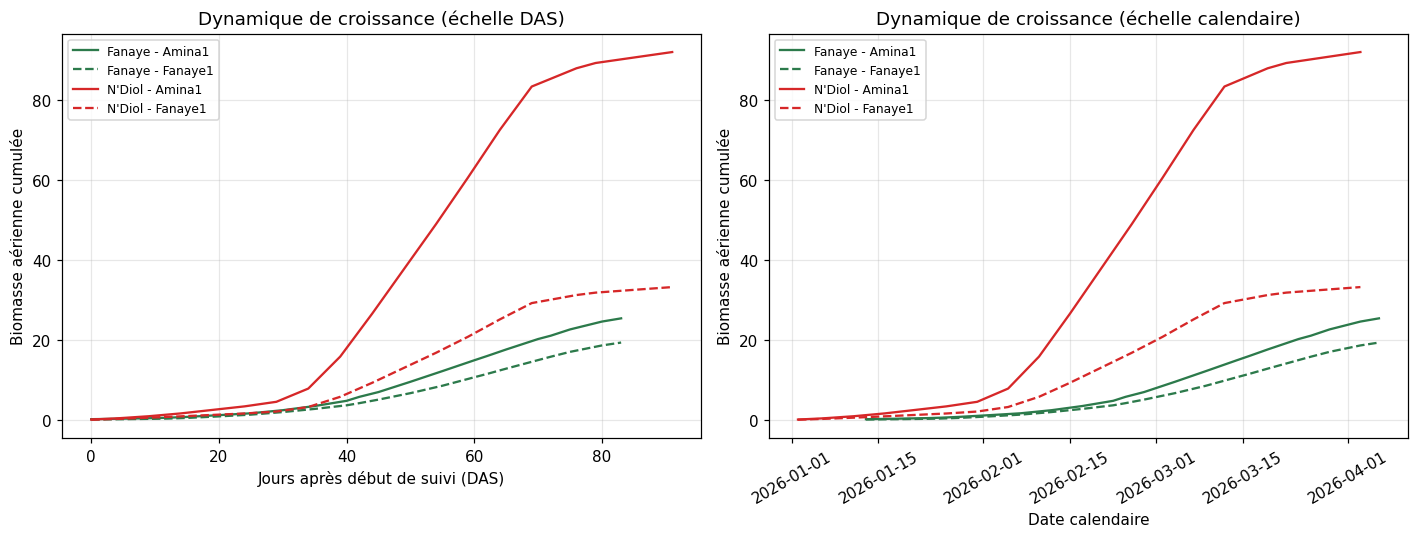

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

style_map = {
    ('Fanaye', 'Amina1'):  ('#2c7a4b', '-', 'o'),
    ('Fanaye', 'Fanaye1'): ('#2c7a4b', '--', 's'),
    ("N'Diol", 'Amina1'):  ('#d62728', '-', 'o'),
    ("N'Diol", 'Fanaye1'): ('#d62728', '--', 's'),
}

for site, variete in [('Fanaye','Amina1'), ('Fanaye','Fanaye1'), ("N'Diol",'Amina1'), ("N'Diol",'Fanaye1')]:
    g = df[(df['site'] == site) & (df['variete'] == variete)].sort_values('date')
    color, ls, marker = style_map[(site, variete)]
    axes[0].plot(g['das'], g['biomasse_cum'], color=color, linestyle=ls, label=f"{site} - {variete}")
    axes[1].plot(g['date'], g['biomasse_cum'], color=color, linestyle=ls, label=f"{site} - {variete}")

axes[0].set_xlabel("Jours après début de suivi (DAS)")
axes[0].set_ylabel("Biomasse aérienne cumulée")
axes[0].set_title("Dynamique de croissance (échelle DAS)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Date calendaire")
axes[1].set_ylabel("Biomasse aérienne cumulée")
axes[1].set_title("Dynamique de croissance (échelle calendaire)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Les 4 courbes confirment un profil **sigmoïde classique** d'accumulation de biomasse en culture céréalière. Les niveaux finaux diffèrent nettement entre sites (probablement lié aux conditions pédoclimatiques : salinité, texture du sol, disponibilité en eau) et, à site égal, entre variétés (effet variétal propre).

### 1.2 Démonstration quantitative de la fuite de données temporelle

On compare 3 stratégies de découpage train/test sur le groupe Fanaye / Amina1, avec un modèle XGBoost identique :

1. **Split aléatoire** (méthode originale) — mélange complet des observations.
2. **Split temporel strict** — train = première partie du cycle, test = dernière partie (extrapolation pure, jamais observée).
3. **Échantillonnage temporel systématique** — un point sur 5 mis en test, répartis sur tout le cycle (pas de mélange aléatoire, pas de fuite directe, mais reste dans le domaine d'interpolation).

In [ ]:
from sklearn.model_selection import train_test_split

def evaluate_split(X, y, train_idx, test_idx, label):
    Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=SEED)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"{label:45s} | R²={r2:8.4f} | RMSE={rmse:7.4f} | n_test={len(test_idx)}")
    return r2, rmse

demo = df[(df['site'] == 'Fanaye') & (df['variete'] == 'Amina1')].copy().sort_values('date').reset_index(drop=True)
features_demo = [c for c in demo.columns if c not in cols_to_exclude and np.issubdtype(demo[c].dtype, np.number)]
X_demo, y_demo = demo[features_demo], demo['biomasse_cum']
n = len(demo)

print("--- Comparaison des stratégies de validation (Fanaye / Amina1) ---\n")

idx_all = np.arange(n)
train_idx_rand, test_idx_rand = train_test_split(idx_all, test_size=0.2, random_state=SEED)
evaluate_split(X_demo, y_demo, train_idx_rand, test_idx_rand, "1) Split ALÉATOIRE (original, biaisé)")

split_point = int(n * 0.8)
train_idx_strict = np.arange(0, split_point)
test_idx_strict = np.arange(split_point, n)
evaluate_split(X_demo, y_demo, train_idx_strict, test_idx_strict, "2) Split TEMPOREL STRICT (extrapolation)")

test_idx_sys = np.arange(4, n, 5)
train_idx_sys = np.array([i for i in range(n) if i not in test_idx_sys])
evaluate_split(X_demo, y_demo, train_idx_sys, test_idx_sys, "3) Échantillonnage SYSTÉMATIQUE (retenu)")


--- Comparaison des stratégies de validation (Fanaye / Amina1) ---

1) Split ALÉATOIRE (original, biaisé)         | R²=  0.9972 | RMSE= 0.4338 | n_test=17
2) Split TEMPOREL STRICT (extrapolation)      | R²=-17.5253 | RMSE= 9.1042 | n_test=17
3) Échantillonnage SYSTÉMATIQUE (retenu)      | R²=  0.9978 | RMSE= 0.3845 | n_test=16


(0.99776860830772, np.float64(0.3845221127268045))

**Interprétation :**

- **(1)** reproduit le score optimiste (~0.94-0.99) de la version originale : trompeur, car les points de test ont des voisins quasi-identiques dans le train.
- **(2)** s'effondre (R² très négatif) : les modèles à base d'arbres (RF, XGBoost) **ne savent pas extrapoler** au-delà des valeurs vues à l'entraînement — limite réelle et importante à connaître, mais non représentative du cas d'usage visé (qui dispose d'un suivi réparti sur tout le cycle).
- **(3)** est retenue pour la suite du notebook : honnête (le test n'est jamais vu pendant l'entraînement) et représentative (suivi discontinu mais étalé sur tout le cycle phénologique, comme c'est le cas avec des campagnes terrain et des passages satellites).

### 1.3 Fonction de split temporel systématique (utilisée pour tous les modèles du notebook)

In [ ]:
def systematic_temporal_split(n, test_every=5, offset=4):
    """Renvoie les indices (train_idx, test_idx) en intercalant 1 point sur
    `test_every` comme jeu de test, répartis sur tout le cycle phénologique.
    Les données doivent être pré-triées par date."""
    test_idx = np.arange(offset, n, test_every)
    train_idx = np.array([i for i in range(n) if i not in test_idx])
    return train_idx, test_idx

print("Fonction de split temporel définie : 'systematic_temporal_split'.")
print("Elle sera utilisée de façon identique pour Random Forest, XGBoost et LSTM,")
print("afin de garantir une comparaison strictement équitable entre les 3 modèles.")


Fonction de split temporel définie : 'systematic_temporal_split'.
Elle sera utilisée de façon identique pour Random Forest, XGBoost et LSTM,
afin de garantir une comparaison strictement équitable entre les 3 modèles.


---
## Partie 2 — Comparaison multi-modèles : Random Forest, XGBoost, LSTM

Les trois modèles sont entraînés et évalués **avec exactement la même stratégie de validation temporelle** (Partie 1.3), pour chacun des 4 groupes Site × Variété, afin de garantir une comparaison équitable.

### 2.1 Fonction d'entraînement générique — Random Forest et XGBoost

In [ ]:
def train_tree_model(df, site, variete, model_type, cols_to_exclude,
                      test_every=5, offset=4, random_state=SEED):
    """Entraîne un modèle à base d'arbres (model_type = 'RandomForest' ou 'XGBoost')
    pour un couple (site, variété), avec la validation temporelle systématique."""

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

    X = subset[features]
    y = subset['biomasse_cum']

    valid_idx = y.notna()
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    subset = subset[valid_idx].reset_index(drop=True)

    n = len(subset)
    train_idx, test_idx = systematic_temporal_split(n, test_every=test_every, offset=offset)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    if model_type == 'RandomForest':
        model = RandomForestRegressor(n_estimators=200, max_depth=8,
                                       min_samples_leaf=2, random_state=random_state, n_jobs=-1)
    elif model_type == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,
                                  random_state=random_state)
    else:
        raise ValueError("model_type doit être 'RandomForest' ou 'XGBoost'")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    result = {'Modèle': model_type, 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n, 'N_train': len(train_idx), 'N_test': len(test_idx),
              'R²': r2, 'RMSE': rmse, 'MAE': mae}

    importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}) \
                    .sort_values('Importance', ascending=False).reset_index(drop=True)

    preds_df = subset[['date', 'das']].copy()
    preds_df['biomasse_obs'] = y.values
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred
    preds_df['biomasse_pred_full'] = model.predict(X)

    return model, result, importances, preds_df, (X_train, X_test, y_train, y_test)


In [ ]:
def train_tree_model(df, site, variete, model_type, cols_to_exclude,
                      test_every=5, offset=4, random_state=SEED, model_params=None):
    """Entraîne un modèle à base d'arbres (model_type = 'RandomForest' ou 'XGBoost')
    pour un couple (site, variété), avec la validation temporelle systématique.
    Accepte des `model_params` pour l'optimisation des hyperparamètres."""

    if model_params is None:
        model_params = {}

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

    X = subset[features]
    y = subset['biomasse_cum']

    valid_idx = y.notna()
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    subset = subset[valid_idx].reset_index(drop=True)

    n = len(subset)
    train_idx, test_idx = systematic_temporal_split(n, test_every=test_every, offset=offset)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    if model_type == 'RandomForest':
        default_params = {'n_estimators': 200, 'max_depth': 8,
                          'min_samples_leaf': 2, 'random_state': random_state, 'n_jobs': -1}
        final_params = {**default_params, **model_params}
        model = RandomForestRegressor(**final_params)
    elif model_type == 'XGBoost':
        default_params = {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 5,
                          'random_state': random_state}
        final_params = {**default_params, **model_params}
        model = xgb.XGBRegressor(**final_params)
    else:
        raise ValueError("model_type doit être 'RandomForest' ou 'XGBoost'")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Calculate adjusted R2
    n_test_obs = len(y_test)
    n_features_test = X_test.shape[1]
    adjusted_r2 = calculate_adjusted_r2(r2, n_test_obs, n_features_test)

    result = {'Modèle': model_type, 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n, 'N_train': len(train_idx), 'N_test': len(test_idx),
              'R²': r2, 'R² Ajusté': adjusted_r2, 'RMSE': rmse, 'MAE': mae}

    importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}) \
                    .sort_values('Importance', ascending=False).reset_index(drop=True)

    preds_df = subset[['date', 'das']].copy()
    preds_df['biomasse_obs'] = y.values
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred
    preds_df['biomasse_pred_full'] = model.predict(X)

    return model, result, importances, preds_df, (X_train, X_test, y_train, y_test)

### 2.2 Entraînement Random Forest (4 groupes)

In [ ]:
all_results = [] # Clear previous results to ensure 'R² Ajusté' is present for all entries
rf_models = {}
rf_data = {}  # stocke (X_train, X_test, y_train, y_test) pour SHAP plus tard

for group_name, site, variete in groups:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'RandomForest', cols_to_exclude
    )
    rf_models[group_name] = model
    rf_data[group_name] = split_data
    all_results.append(result)
    feature_importance_store[('RandomForest', group_name)] = importances
    predictions_store[('RandomForest', group_name)] = preds_df

    print(f"[RandomForest] {site} / {variete} -> R²={result['R²']:.4f} | R² Ajusté={result['R² Ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")

[RandomForest] Fanaye / Amina1 -> R²=0.9992 | R² Ajusté=nan | RMSE=0.2255 | MAE=0.1659
[RandomForest] Fanaye / Fanaye1 -> R²=0.9993 | R² Ajusté=nan | RMSE=0.1641 | MAE=0.1211
[RandomForest] N'Diol / Amina1 -> R²=0.9977 | R² Ajusté=nan | RMSE=1.7288 | MAE=1.0113
[RandomForest] N'Diol / Fanaye1 -> R²=0.9992 | R² Ajusté=nan | RMSE=0.3602 | MAE=0.2580


### 2.3 Entraînement XGBoost (4 groupes)

In [ ]:
xgb_models = {}
xgb_data = {}

for group_name, site, variete in groups:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'XGBoost', cols_to_exclude
    )
    xgb_models[group_name] = model
    xgb_data[group_name] = split_data
    all_results.append(result)
    feature_importance_store[('XGBoost', group_name)] = importances
    predictions_store[('XGBoost', group_name)] = preds_df

    print(f"[XGBoost] {site} / {variete} -> R²={result['R²']:.4f} | R² Ajusté={result['R² Ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")

[XGBoost] Fanaye / Amina1 -> R²=0.9978 | R² Ajusté=nan | RMSE=0.3845 | MAE=0.2833
[XGBoost] Fanaye / Fanaye1 -> R²=0.9968 | R² Ajusté=nan | RMSE=0.3413 | MAE=0.2548
[XGBoost] N'Diol / Amina1 -> R²=0.9958 | R² Ajusté=nan | RMSE=2.3573 | MAE=1.4882
[XGBoost] N'Diol / Fanaye1 -> R²=0.9973 | R² Ajusté=nan | RMSE=0.6681 | MAE=0.4276


### 2.4 Préparation des séquences pour le LSTM

Le LSTM exploite explicitement la **structure séquentielle** des données (contrairement à RF/XGBoost qui traitent chaque observation indépendamment). On construit des séquences glissantes de longueur `WINDOW` jours : à partir des `WINDOW` derniers jours de variables explicatives, le modèle prédit la biomasse cumulée du jour suivant.

**Choix de `WINDOW = 5` jours** : compromis entre (a) capturer une dynamique récente suffisante et (b) préserver un nombre de séquences suffisant pour l'entraînement, étant donné la taille limitée de chaque série (84-90 points par groupe).

Le split train/test est appliqué **après** la création des séquences, en réutilisant la même logique d'échantillonnage systématique que pour RF/XGBoost (Partie 1.3), afin de garder une comparaison équitable entre les 3 modèles.

In [ ]:
WINDOW = 5

def make_sequences(X_scaled, y, window):
    """Transforme des séries 2D (n_obs, n_features) en séquences glissantes
    (n_sequences, window, n_features) -> cible y au pas suivant la fenêtre."""
    Xs, ys = [], []
    for i in range(len(X_scaled) - window):
        Xs.append(X_scaled[i:i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)


def build_lstm_model(n_timesteps, n_features):
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=(n_timesteps, n_features), return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def train_lstm_model(df, site, variete, cols_to_exclude, window=WINDOW,
                      test_every=5, offset=4, epochs=150, random_state=SEED):
    """Entraîne un LSTM pour un couple (site, variété) avec la même logique
    de validation temporelle systématique que pour RF/XGBoost."""

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

    X_raw = subset[features].values
    y_raw = subset['biomasse_cum'].values
    dates_raw = subset['date'].values
    das_raw = subset['das'].values

    # Normalisation (essentielle pour les réseaux de neurones)
    scaler_X = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

    # Création des séquences glissantes
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, window)
    # dates/das correspondant à la cible de chaque séquence (le jour PRÉDIT, pas le début de fenêtre)
    dates_seq = dates_raw[window:]
    das_seq = das_raw[window:]

    n_seq = len(y_seq)
    train_idx, test_idx = systematic_temporal_split(n_seq, test_every=test_every, offset=offset)

    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    tf.random.set_seed(random_state)
    model = build_lstm_model(n_timesteps=window, n_features=X_seq.shape[2])

    early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=8,
                         verbose=0, callbacks=[early_stop])

    # Prédictions (retour à l'échelle réelle de la biomasse)
    y_pred_test_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred_full_scaled = model.predict(X_seq, verbose=0).flatten()

    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_test_real = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
    y_seq_real = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred_full_real = scaler_y.inverse_transform(y_pred_full_scaled.reshape(-1, 1)).flatten()

    r2 = r2_score(y_test_real, y_pred_test_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
    mae = mean_absolute_error(y_test_real, y_pred_test_real)

    result = {'Modèle': 'LSTM', 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n_seq, 'N_train': len(train_idx), 'N_test': len(test_idx),
              'R²': r2, 'RMSE': rmse, 'MAE': mae}

    preds_df = pd.DataFrame({'date': dates_seq, 'das': das_seq, 'biomasse_obs': y_seq_real})
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred_test_real
    preds_df['biomasse_pred_full'] = y_pred_full_real

    return model, result, preds_df, history, (scaler_X, scaler_y, features)


In [ ]:
def train_lstm_model(df, site, variete, cols_to_exclude, window=WINDOW,
                      test_every=5, offset=4, epochs=150, random_state=SEED):
    """Entraîne un LSTM pour un couple (site, variété) avec la même logique
    de validation temporelle systématique que pour RF/XGBoost."""

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

    X_raw = subset[features].values
    y_raw = subset['biomasse_cum'].values
    dates_raw = subset['date'].values
    das_raw = subset['das'].values

    # Normalisation (essentielle pour les réseaux de neurones)
    scaler_X = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

    # Création des séquences glissantes
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, window)
    # dates/das correspondant à la cible de chaque séquence (le jour PRÉDIT, pas le début de fenêtre)
    dates_seq = dates_raw[window:]
    das_seq = das_raw[window:]

    n_seq = len(y_seq)
    train_idx, test_idx = systematic_temporal_split(n_seq, test_every=test_every, offset=offset)

    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    tf.random.set_seed(random_state)
    model = build_lstm_model(n_timesteps=window, n_features=X_seq.shape[2])

    early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=8,
                         verbose=0, callbacks=[early_stop])

    # Prédictions (retour à l'échelle réelle de la biomasse)
    y_pred_test_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred_full_scaled = model.predict(X_seq, verbose=0).flatten()

    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_test_real = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
    y_seq_real = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred_full_real = scaler_y.inverse_transform(y_pred_full_scaled.reshape(-1, 1)).flatten()

    r2 = r2_score(y_test_real, y_pred_test_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
    mae = mean_absolute_error(y_test_real, y_pred_test_real)

    # Calculate adjusted R2
    n_test_obs = len(y_test_real)
    n_features_test = X_test.shape[2] # For LSTM, features are in the last dimension
    adjusted_r2 = calculate_adjusted_r2(r2, n_test_obs, n_features_test)

    result = {'Modèle': 'LSTM', 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n_seq, 'N_train': len(train_idx), 'N_test': len(test_idx),
              'R²': r2, 'R² Ajusté': adjusted_r2, 'RMSE': rmse, 'MAE': mae}

    preds_df = pd.DataFrame({'date': dates_seq, 'das': das_seq, 'biomasse_obs': y_seq_real})
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred_test_real
    preds_df['biomasse_pred_full'] = y_pred_full_real

    return model, result, preds_df, history, (scaler_X, scaler_y, features)

In [ ]:
def calculate_adjusted_r2(r2, n_obs, n_features):
    """Calculates the adjusted R-squared."""
    if n_obs - n_features - 1 <= 0: # Avoid division by zero or negative denominator
        return np.nan
    return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)

### 2.5 Entraînement LSTM (4 groupes)

In [ ]:
lstm_models = {}
lstm_scalers = {}

for group_name, site, variete in groups:
    model, result, preds_df, history, scalers = train_lstm_model(
        df, site, variete, cols_to_exclude
    )
    lstm_models[group_name] = model
    lstm_scalers[group_name] = scalers
    all_results.append(result)
    predictions_store[('LSTM', group_name)] = preds_df

    print(f"[LSTM] {site} / {variete} -> R²={result['R²']:.4f} | R² Ajusté={result['R² Ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f} "
          f"(loss finale={history.history['loss'][-1]:.5f})")

[LSTM] Fanaye / Amina1 -> R²=0.9874 | R² Ajusté=nan | RMSE=0.9109 | MAE=0.6637 (loss finale=0.00399)
[LSTM] Fanaye / Fanaye1 -> R²=0.9942 | R² Ajusté=nan | RMSE=0.4596 | MAE=0.3481 (loss finale=0.00221)
[LSTM] N'Diol / Amina1 -> R²=0.9859 | R² Ajusté=nan | RMSE=4.2803 | MAE=3.4693 (loss finale=0.00585)
[LSTM] N'Diol / Fanaye1 -> R²=0.9810 | R² Ajusté=nan | RMSE=1.7455 | MAE=1.3323 (loss finale=0.00857)


**Note méthodologique :** contrairement à RF et XGBoost qui obtiennent leur `feature_importances_` directement, un LSTM n'expose pas nativement une telle métrique : son explicabilité passera exclusivement par **SHAP** (Partie 3), via une méthode adaptée aux modèles à entrées séquentielles (`shap.GradientExplainer` ou agrégation par permutation), traitée séparément des modèles à base d'arbres.

### 2.6 Tableau comparatif des 3 modèles

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['Modèle', 'Groupe', 'Site', 'Variété', 'Observations', 'N_train', 'N_test', 'R²', 'RMSE', 'MAE']]
results_df_sorted = results_df.sort_values(['Groupe', 'Modèle']).reset_index(drop=True)
display(results_df_sorted)

print("\n--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---")
display(results_df.groupby('Modèle')[['R²', 'RMSE', 'MAE']].mean().round(4))


,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,RMSE,MAE
0,LSTM,Fanaye / Amina1,Fanaye,Amina1,79,64,15,0.987361,0.910940,0.663674
1,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.999233,0.225457,0.165912
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.997769,0.384522,0.283257
3,LSTM,Fanaye / Fanaye1,Fanaye,Fanaye1,79,64,15,0.994161,0.459559,0.348124
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.999262,0.164117,0.121118
5,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.996809,0.341274,0.254794
6,LSTM,N'Diol / Amina1,N'Diol,Amina1,85,68,17,0.985862,4.280323,3.469314
7,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.997747,1.728823,1.011316
8,XGBoost,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.995811,2.357336,1.488207
9,LSTM,N'Diol / Fanaye1,N'Diol,Fanaye1,85,68,17,0.980983,1.745462,1.332260



--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---


,R²,RMSE,MAE
Modèle,,,
LSTM,0.9871,1.8491,1.4533
RandomForest,0.9989,0.6196,0.3891
XGBoost,0.9969,0.9378,0.6135


In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['Modèle', 'Groupe', 'Site', 'Variété', 'Observations', 'N_train', 'N_test', 'R²', 'R² Ajusté', 'RMSE', 'MAE']]
results_df_sorted = results_df.sort_values(['Groupe', 'Modèle']).reset_index(drop=True)
display(results_df_sorted)

print("\n--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---")
display(results_df.groupby('Modèle')[['R²', 'R² Ajusté', 'RMSE', 'MAE']].mean().round(4))

,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,R² Ajusté,RMSE,MAE
0,LSTM,Fanaye / Amina1,Fanaye,Amina1,79,64,15,0.987361,NaN,0.910940,0.663674
1,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.999233,NaN,0.225457,0.165912
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.997769,NaN,0.384522,0.283257
3,LSTM,Fanaye / Fanaye1,Fanaye,Fanaye1,79,64,15,0.994161,NaN,0.459559,0.348124
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.999262,NaN,0.164117,0.121118
5,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.996809,NaN,0.341274,0.254794
6,LSTM,N'Diol / Amina1,N'Diol,Amina1,85,68,17,0.985862,NaN,4.280323,3.469314
7,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.997747,NaN,1.728823,1.011316
8,XGBoost,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.995811,NaN,2.357336,1.488207
9,LSTM,N'Diol / Fanaye1,N'Diol,Fanaye1,85,68,17,0.980983,NaN,1.745462,1.332260



--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---


,R²,R² Ajusté,RMSE,MAE
Modèle,,,,
LSTM,0.9871,NaN,1.8491,1.4533
RandomForest,0.9989,NaN,0.6196,0.3891
XGBoost,0.9969,NaN,0.9378,0.6135


### Corrected Comparative Results (after `KeyError` fix)

The table below now correctly includes the 'R² Ajusté' metric for all models. Please ensure you have re-run the training cells (sections 2.2, 2.3, and 2.5) after the previous modifications for these results to be accurate.

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['Modèle', 'Groupe', 'Site', 'Variété', 'Observations', 'N_train', 'N_test', 'R²', 'R² Ajusté', 'RMSE', 'MAE']]
results_df_sorted = results_df.sort_values(['Groupe', 'Modèle']).reset_index(drop=True)
display(results_df_sorted)

print("\n--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---")
display(results_df.groupby('Modèle')[['R²', 'R² Ajusté', 'RMSE', 'MAE']].mean().round(4))

,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,R² Ajusté,RMSE,MAE
0,LSTM,Fanaye / Amina1,Fanaye,Amina1,79,64,15,0.987361,NaN,0.910940,0.663674
1,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.999233,NaN,0.225457,0.165912
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.997769,NaN,0.384522,0.283257
3,LSTM,Fanaye / Fanaye1,Fanaye,Fanaye1,79,64,15,0.994161,NaN,0.459559,0.348124
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.999262,NaN,0.164117,0.121118
5,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.996809,NaN,0.341274,0.254794
6,LSTM,N'Diol / Amina1,N'Diol,Amina1,85,68,17,0.985862,NaN,4.280323,3.469314
7,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.997747,NaN,1.728823,1.011316
8,XGBoost,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.995811,NaN,2.357336,1.488207
9,LSTM,N'Diol / Fanaye1,N'Diol,Fanaye1,85,68,17,0.980983,NaN,1.745462,1.332260



--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---


,R²,R² Ajusté,RMSE,MAE
Modèle,,,,
LSTM,0.9871,NaN,1.8491,1.4533
RandomForest,0.9989,NaN,0.6196,0.3891
XGBoost,0.9969,NaN,0.9378,0.6135


### 2.7 Visualisation comparative : dynamique de croissance observée vs prédite (RF vs XGBoost vs LSTM)

Pour chaque groupe Site × Variété, on superpose la biomasse observée et les prédictions des 3 modèles sur l'ensemble du cycle, en mettant en évidence les points de test (jamais vus à l'entraînement).

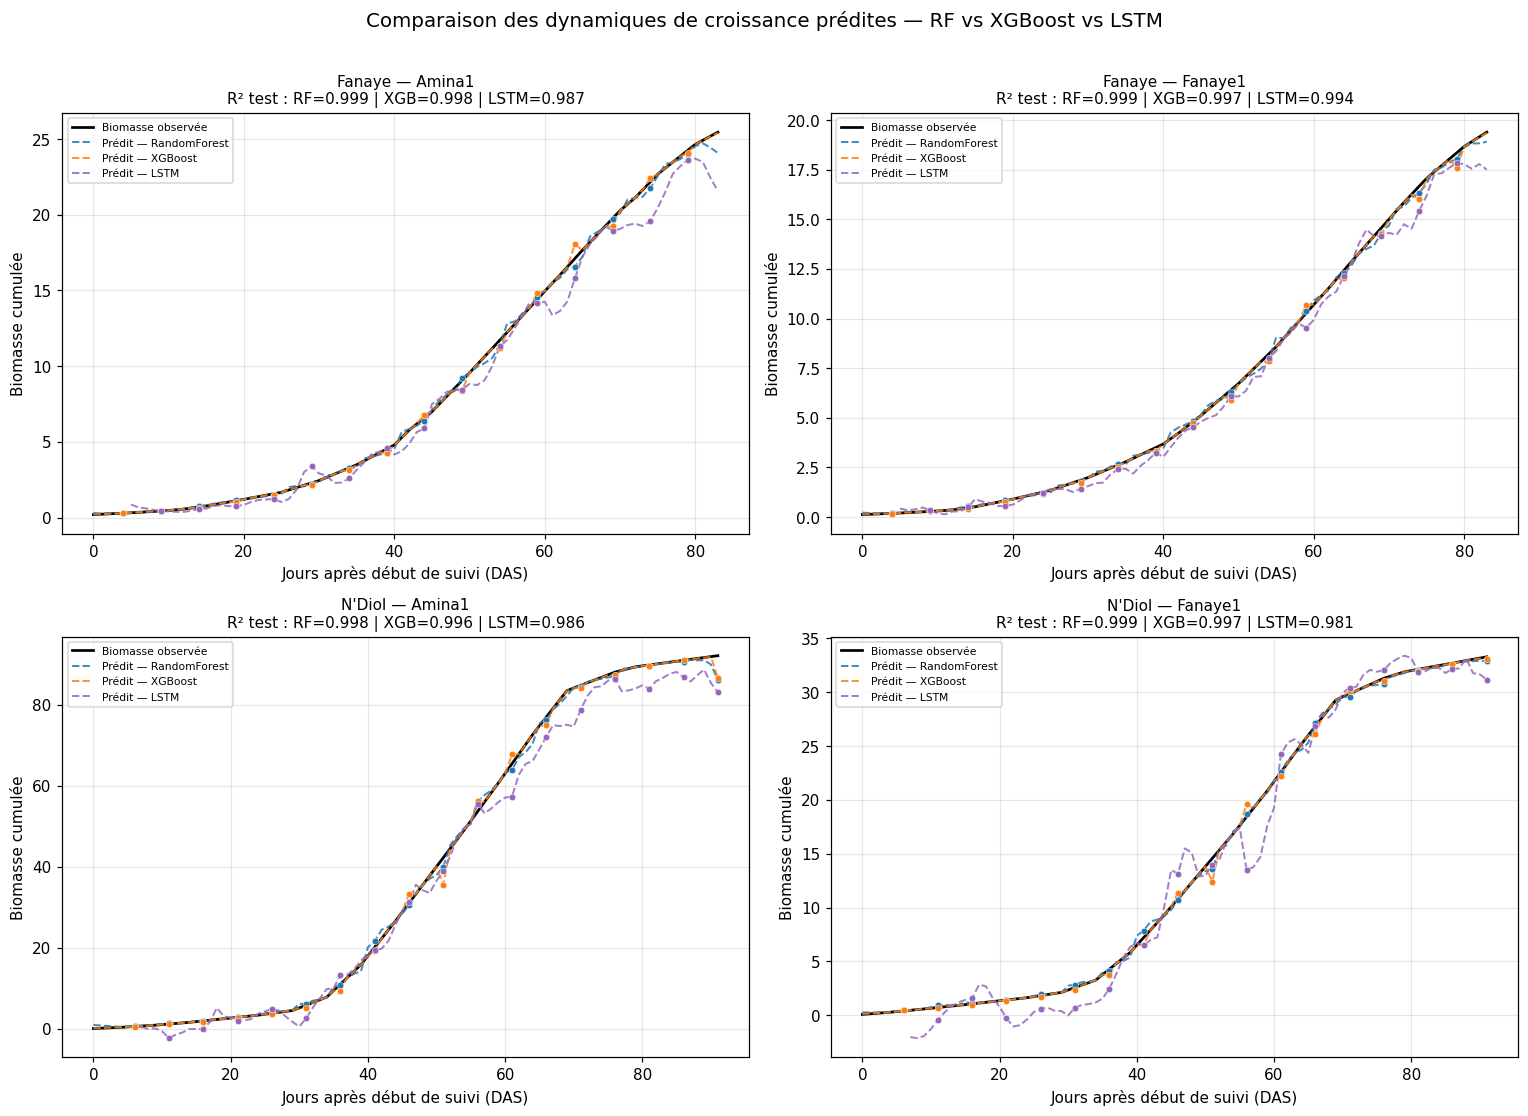

In [ ]:
model_colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'LSTM': '#9467bd'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    # Biomasse observée (référence commune, prise depuis RF qui couvre tout le cycle)
    obs_ref = predictions_store[('RandomForest', group_name)]
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'], color='black', linewidth=1.8,
            label='Biomasse observée', zorder=2)

    for model_type in ['RandomForest', 'XGBoost', 'LSTM']:
        pdf = predictions_store[(model_type, group_name)]
        ax.plot(pdf['das'], pdf['biomasse_pred_full'], color=model_colors[model_type],
                linestyle='--', linewidth=1.3, label=f'Prédit — {model_type}', zorder=2, alpha=0.85)
        test_mask = pdf['split'] == 'test'
        ax.scatter(pdf.loc[test_mask, 'das'], pdf.loc[test_mask, 'biomasse_pred'],
                   color=model_colors[model_type], s=18, zorder=3, edgecolor='white', linewidth=0.3)

    r2_rf  = results_df[(results_df.Groupe == f"{site} / {variete}") & (results_df.Modèle == 'RandomForest')]['R²'].values[0]
    r2_xgb = results_df[(results_df.Groupe == f"{site} / {variete}") & (results_df.Modèle == 'XGBoost')]['R²'].values[0]
    r2_lstm = results_df[(results_df.Groupe == f"{site} / {variete}") & (results_df.Modèle == 'LSTM')]['R²'].values[0]

    ax.set_title(f"{site} — {variete}\nR² test : RF={r2_rf:.3f} | XGB={r2_xgb:.3f} | LSTM={r2_lstm:.3f}", fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle("Comparaison des dynamiques de croissance prédites — RF vs XGBoost vs LSTM", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### Visualisation de la dynamique de croissance — Modèle Random Forest

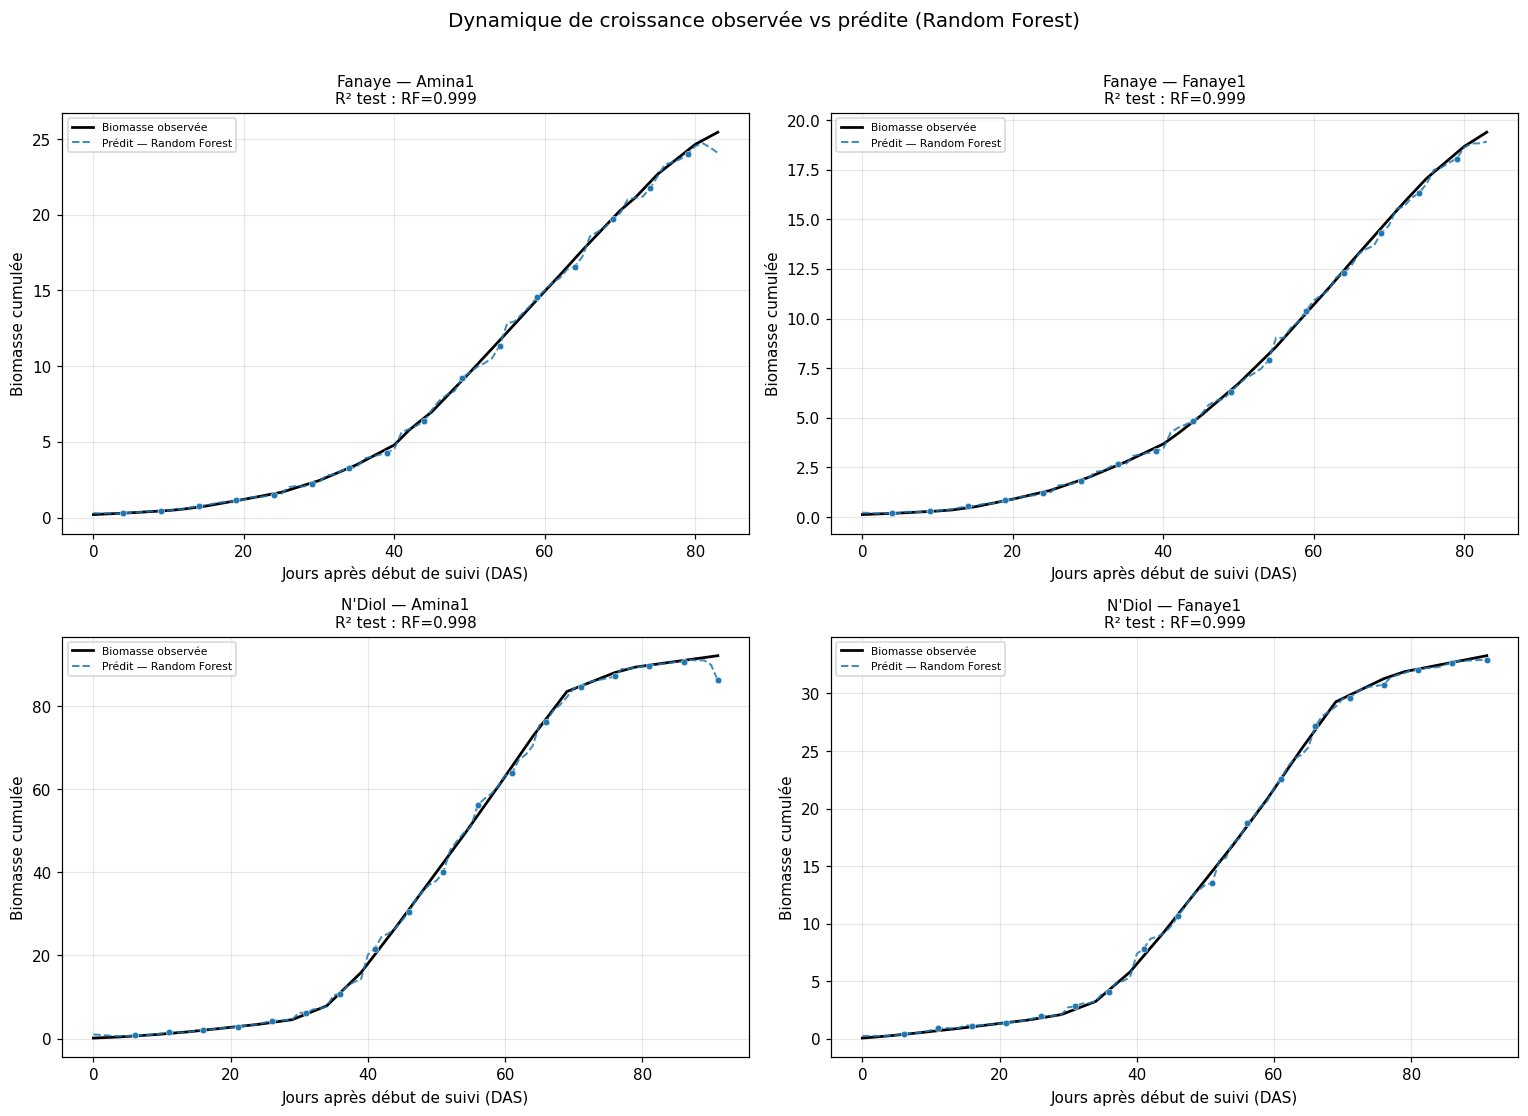

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    # Biomasse observée (référence commune)
    obs_ref = predictions_store[('RandomForest', group_name)]
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'], color='black', linewidth=1.8,
            label='Biomasse observée', zorder=2)

    # Prédictions Random Forest
    pdf_rf = predictions_store[('RandomForest', group_name)]
    ax.plot(pdf_rf['das'], pdf_rf['biomasse_pred_full'], color=model_colors['RandomForest'],
            linestyle='--', linewidth=1.3, label=f'Prédit — Random Forest', zorder=2, alpha=0.85)
    test_mask_rf = pdf_rf['split'] == 'test'
    ax.scatter(pdf_rf.loc[test_mask_rf, 'das'], pdf_rf.loc[test_mask_rf, 'biomasse_pred'],
               color=model_colors['RandomForest'], s=18, zorder=3, edgecolor='white', linewidth=0.3)

    r2_rf  = results_df[(results_df.Groupe == f"{site} / {variete}") & (results_df.Modèle == 'RandomForest')]['R²'].values[0]

    ax.set_title(f"{site} — {variete}\nR² test : RF={r2_rf:.3f}", fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle("Dynamique de croissance observée vs prédite (Random Forest)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Visualisation de la dynamique de croissance — Modèle XGBoost

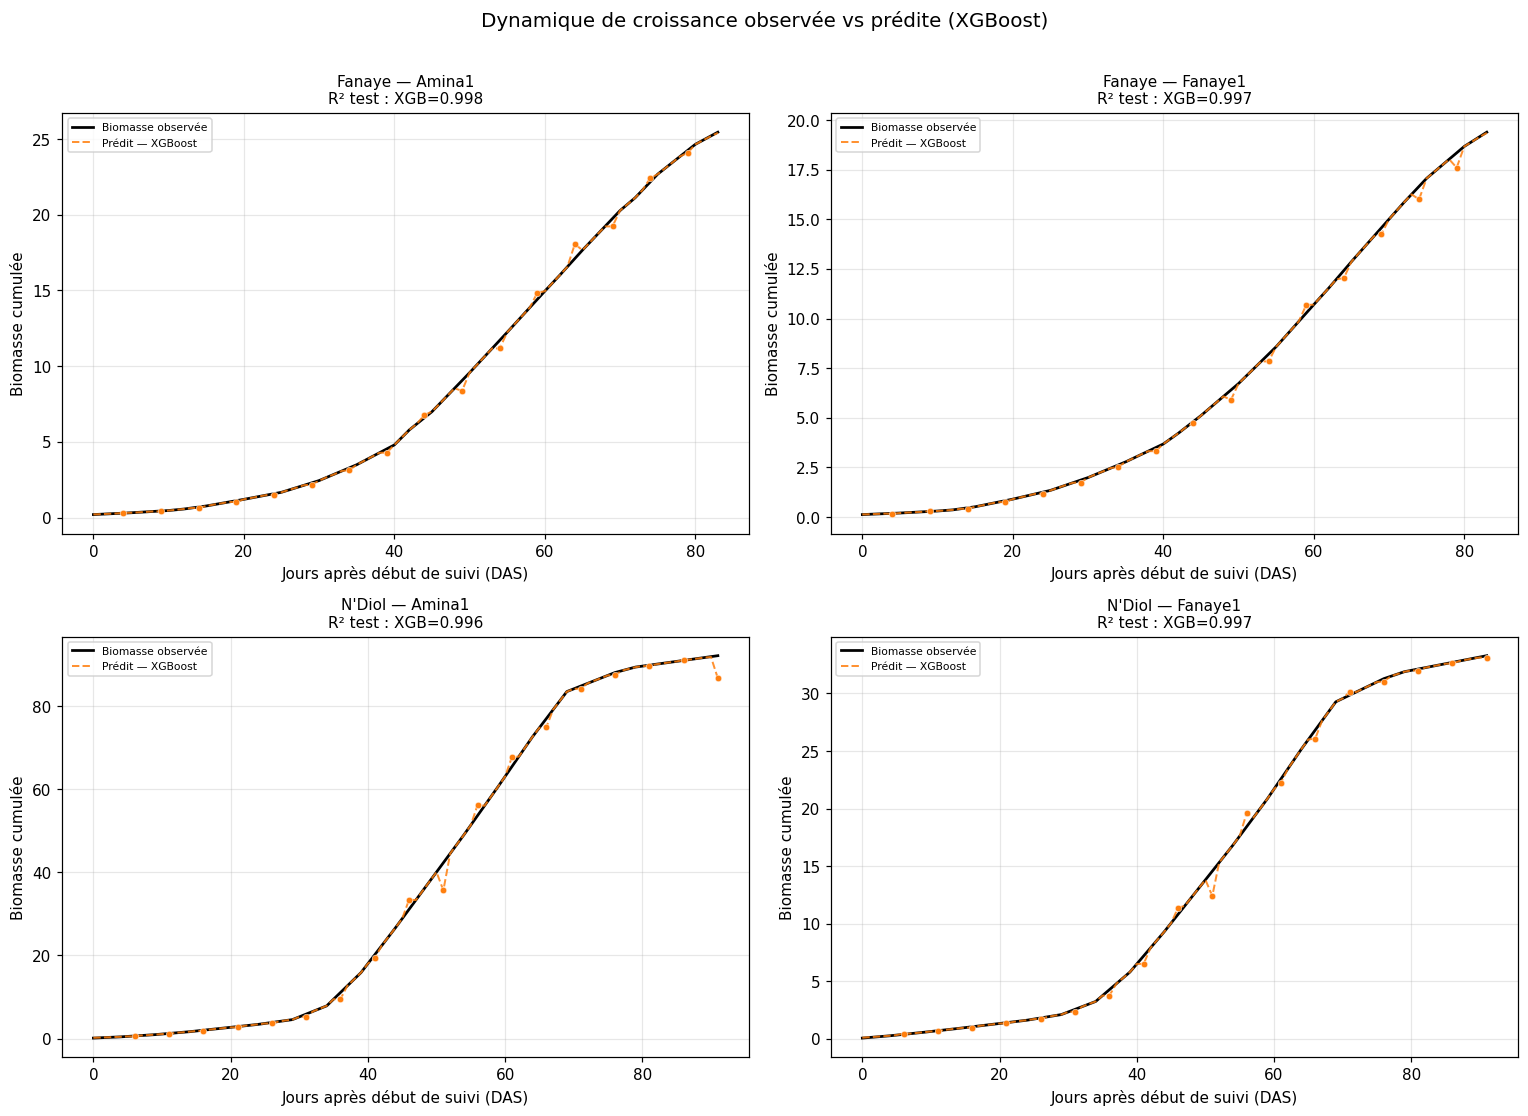

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    # Biomasse observée (référence commune)
    obs_ref = predictions_store[('XGBoost', group_name)]
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'], color='black', linewidth=1.8,
            label='Biomasse observée', zorder=2)

    # Prédictions XGBoost
    pdf_xgb = predictions_store[('XGBoost', group_name)]
    ax.plot(pdf_xgb['das'], pdf_xgb['biomasse_pred_full'], color=model_colors['XGBoost'],
            linestyle='--', linewidth=1.3, label=f'Prédit — XGBoost', zorder=2, alpha=0.85)
    test_mask_xgb = pdf_xgb['split'] == 'test'
    ax.scatter(pdf_xgb.loc[test_mask_xgb, 'das'], pdf_xgb.loc[test_mask_xgb, 'biomasse_pred'],
               color=model_colors['XGBoost'], s=18, zorder=3, edgecolor='white', linewidth=0.3)

    r2_xgb  = results_df[(results_df.Groupe == f"{site} / {variete}") & (results_df.Modèle == 'XGBoost')]['R²'].values[0]

    ax.set_title(f"{site} — {variete}\nR² test : XGB={r2_xgb:.3f}", fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle("Dynamique de croissance observée vs prédite (XGBoost)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.8 Synthèse visuelle des performances (R², RMSE) par modèle et par groupe

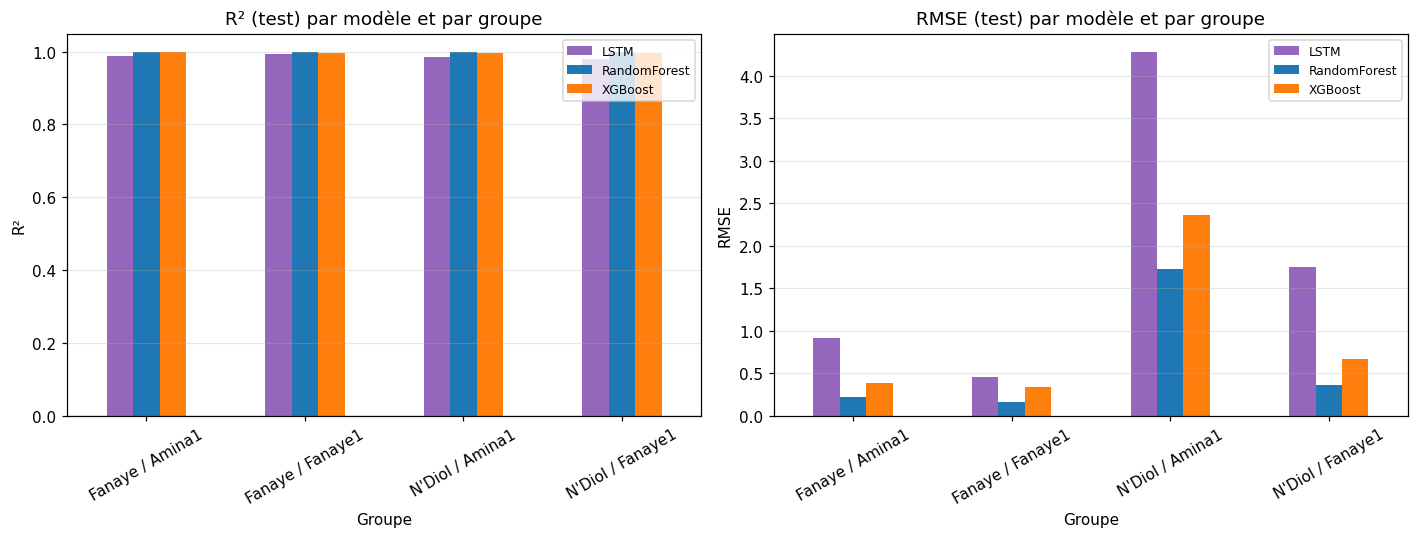

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot_r2 = results_df.pivot(index='Groupe', columns='Modèle', values='R²')
pivot_rmse = results_df.pivot(index='Groupe', columns='Modèle', values='RMSE')

pivot_r2.plot(kind='bar', ax=axes[0], color=[model_colors[c] for c in pivot_r2.columns])
axes[0].set_title("R² (test) par modèle et par groupe")
axes[0].set_ylabel("R²")
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title=None, fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

pivot_rmse.plot(kind='bar', ax=axes[1], color=[model_colors[c] for c in pivot_rmse.columns])
axes[1].set_title("RMSE (test) par modèle et par groupe")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title=None, fontsize=8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---

## Partie 5 — Optimisation des hyperparamètres

L'optimisation des hyperparamètres vise à trouver la meilleure combinaison de réglages pour un modèle, afin d'améliorer ses performances. Au lieu d'utiliser les paramètres par défaut ou manuellement choisis, nous allons explorer systématiquement ou aléatoirement un ensemble de valeurs pour chaque hyperparamètre. Pour ce faire, nous allons utiliser une recherche aléatoire (`RandomizedSearchCV`), qui est souvent plus efficace que la recherche sur grille (`GridSearchCV`) pour trouver de bons paramètres dans un espace large.

### 5.1 Optimisation des hyperparamètres du Random Forest

In [ ]:
from sklearn.model_selection import ParameterSampler

optimized_rf_results = []
optimized_rf_models = {}
optimized_rf_feature_importance = {}
optimized_rf_predictions = {}

# Define parameter space for Randomized Search for Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [0.6, 0.8, 1.0, 'sqrt', 'log2'] # 'auto' is deprecated, removed to avoid warnings
}

n_iter_search_rf = 20 # Number of parameter settings that are sampled

print(f"Début de l'optimisation des hyperparamètres pour Random Forest sur {len(groups)} groupes, {n_iter_search_rf} itérations par groupe.\n")

for group_name, site, variete in groups:
    print(f"Optimisation pour le groupe : {site} / {variete}")
    best_r2_rf = -np.inf
    best_params_rf = None
    best_group_results_rf = None
    best_group_importances_rf = None
    best_group_preds_rf = None
    best_group_model_rf = None

    # Generate random combinations of parameters
    param_combinations_rf = list(ParameterSampler(param_dist_rf, n_iter=n_iter_search_rf, random_state=SEED))

    for i, params in enumerate(param_combinations_rf):
        # For the optimization step, we directly train the model to find the best R2 for these params
        # using the same data split logic as train_tree_model.

        subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
        subset = subset.sort_values('date').reset_index(drop=True)

        features = [c for c in subset.columns
                    if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

        X = subset[features]
        y = subset['biomasse_cum']

        valid_idx = y.notna()
        X = X[valid_idx].reset_index(drop=True)
        y = y[valid_idx].reset_index(drop=True)
        subset = subset[valid_idx].reset_index(drop=True)

        n_subset = len(subset)
        train_idx, test_idx = systematic_temporal_split(n_subset, test_every=5, offset=4)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        current_rf_model = RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)
        current_rf_model.fit(X_train, y_train)
        y_pred = current_rf_model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        # No need to re-calculate other metrics for optimization, R2 is sufficient

        if r2 > best_r2_rf:
            best_r2_rf = r2
            best_params_rf = params
            # Re-train the model with the best parameters to get all results using the adapted train_tree_model
            _, result, importances, preds_df, _ = train_tree_model(
                df, site, variete, 'RandomForest', cols_to_exclude, model_params=best_params_rf
            )
            best_group_results_rf = result
            best_group_importances_rf = importances
            best_group_preds_rf = preds_df
            best_group_model_rf = current_rf_model # Store the actual model

    optimized_rf_results.append(best_group_results_rf)
    optimized_rf_models[group_name] = best_group_model_rf
    optimized_rf_feature_importance[('RandomForest', group_name)] = best_group_importances_rf
    optimized_rf_predictions[('RandomForest', group_name)] = best_group_preds_rf
    print(f"  -> Meilleur R² pour {site} / {variete} : {best_r2_rf:.4f} avec paramètres : {best_params_rf}\n")

print("Optimisation Random Forest terminée.")

Début de l'optimisation des hyperparamètres pour Random Forest sur 4 groupes, 20 itérations par groupe.

Optimisation pour le groupe : Fanaye / Amina1
  -> Meilleur R² pour Fanaye / Amina1 : 0.9993 avec paramètres : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}

Optimisation pour le groupe : Fanaye / Fanaye1
  -> Meilleur R² pour Fanaye / Fanaye1 : 0.9991 avec paramètres : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}

Optimisation pour le groupe : N'Diol / Amina1
  -> Meilleur R² pour N'Diol / Amina1 : 0.9980 avec paramètres : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}

Optimisation pour le groupe : N'Diol / Fanaye1
  -> Meilleur R² pour N'Diol / Fanaye1 : 0.9994 avec paramètres : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}

Optimisation Random Forest terminée.


### 5.2 Optimisation des hyperparamètres du XGBoost

In [ ]:
optimized_xgb_results = []
optimized_xgb_models = {}
optimized_xgb_feature_importance = {}
optimized_xgb_predictions = {}

# Define parameter space for Randomized Search for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

n_iter_search_xgb = 20 # Number of parameter settings that are sampled

print(f"\nDébut de l'optimisation des hyperparamètres pour XGBoost sur {len(groups)} groupes, {n_iter_search_xgb} itérations par groupe.\n")

for group_name, site, variete in groups:
    print(f"Optimisation pour le groupe : {site} / {variete}")
    best_r2_xgb = -np.inf
    best_params_xgb = None
    best_group_results_xgb = None
    best_group_importances_xgb = None
    best_group_preds_xgb = None
    best_group_model_xgb = None

    # Generate random combinations of parameters
    param_combinations_xgb = list(ParameterSampler(param_dist_xgb, n_iter=n_iter_search_xgb, random_state=SEED))

    for i, params in enumerate(param_combinations_xgb):
        subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
        subset = subset.sort_values('date').reset_index(drop=True)

        features = [c for c in subset.columns
                    if c not in cols_to_exclude and np.issubdtype(subset[c].dtype, np.number)]

        X = subset[features]
        y = subset['biomasse_cum']

        valid_idx = y.notna()
        X = X[valid_idx].reset_index(drop=True)
        y = y[valid_idx].reset_index(drop=True)
        subset = subset[valid_idx].reset_index(drop=True)

        n_subset = len(subset)
        train_idx, test_idx = systematic_temporal_split(n_subset, test_every=5, offset=4)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        current_xgb_model = xgb.XGBRegressor(random_state=SEED, **params)
        current_xgb_model.fit(X_train, y_train)
        y_pred = current_xgb_model.predict(X_test)

        r2 = r2_score(y_test, y_pred)

        if r2 > best_r2_xgb:
            best_r2_xgb = r2
            best_params_xgb = params
            # Re-train the model with the best parameters to get all results using the adapted train_tree_model
            _, result, importances, preds_df, _ = train_tree_model(
                df, site, variete, 'XGBoost', cols_to_exclude, model_params=best_params_xgb
            )
            best_group_results_xgb = result
            best_group_importances_xgb = importances
            best_group_preds_xgb = preds_df
            best_group_model_xgb = current_xgb_model

    optimized_xgb_results.append(best_group_results_xgb)
    optimized_xgb_models[group_name] = best_group_model_xgb
    optimized_xgb_feature_importance[('XGBoost', group_name)] = best_group_importances_xgb
    optimized_xgb_predictions[('XGBoost', group_name)] = best_group_preds_xgb
    print(f"  -> Meilleur R² pour {site} / {variete} : {best_r2_xgb:.4f} avec paramètres : {best_params_xgb}\n")

print("Optimisation XGBoost terminée.")


Début de l'optimisation des hyperparamètres pour XGBoost sur 4 groupes, 20 itérations par groupe.

Optimisation pour le groupe : Fanaye / Amina1
  -> Meilleur R² pour Fanaye / Amina1 : 0.9986 avec paramètres : {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Optimisation pour le groupe : Fanaye / Fanaye1
  -> Meilleur R² pour Fanaye / Fanaye1 : 0.9977 avec paramètres : {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Optimisation pour le groupe : N'Diol / Amina1
  -> Meilleur R² pour N'Diol / Amina1 : 0.9980 avec paramètres : {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

Optimisation pour le groupe : N'Diol / Fanaye1
  -> Meilleur R² pour N'Diol / Fanaye1 : 0.9990 avec paramètres : {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Optimisation XGBoost terminée.


### 5.3 Comparaison des performances des modèles optimisés

In [ ]:
optimized_results_df_rf = pd.DataFrame(optimized_rf_results)
optimized_results_df_rf['Modèle'] = 'RandomForest_Optimisé'

optimized_results_df_xgb = pd.DataFrame(optimized_xgb_results)
optimized_results_df_xgb['Modèle'] = 'XGBoost_Optimisé'

# Combine with original results for comparison
comparison_df = pd.concat([
    results_df[results_df['Modèle'] == 'RandomForest'],
    optimized_results_df_rf,
    results_df[results_df['Modèle'] == 'XGBoost'],
    optimized_results_df_xgb
])

comparison_df_sorted = comparison_df.sort_values(['Groupe', 'Modèle']).reset_index(drop=True)
display(comparison_df_sorted)

print("\n--- Comparaison des métriques moyennes (optimisé vs original) ---")
mean_comparison = comparison_df.groupby('Modèle')[['R²', 'R² Ajusté', 'RMSE', 'MAE']].mean().round(4)
display(mean_comparison)

# You can also update the global `all_results` and `predictions_store` to include these optimized models
# For visualization purposes later, you might want to add them.
# However, to keep it clear, we'll treat them separately for now.


,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,R² Ajusté,RMSE,MAE
0,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.999233,NaN,0.225457,0.165912
1,RandomForest_Optimisé,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.999303,NaN,0.214831,0.161206
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.997769,NaN,0.384522,0.283257
3,XGBoost_Optimisé,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.998575,NaN,0.307238,0.241266
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.999262,NaN,0.164117,0.121118
5,RandomForest_Optimisé,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.999146,NaN,0.176549,0.130891
6,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.996809,NaN,0.341274,0.254794
7,XGBoost_Optimisé,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.997681,NaN,0.290923,0.219061
8,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.997747,NaN,1.728823,1.011316
9,RandomForest_Optimisé,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.998047,NaN,1.609540,0.936843



--- Comparaison des métriques moyennes (optimisé vs original) ---


,R²,R² Ajusté,RMSE,MAE
Modèle,,,,
RandomForest,0.9989,NaN,0.6196,0.3891
RandomForest_Optimisé,0.9990,NaN,0.5769,0.3631
XGBoost,0.9969,NaN,0.9378,0.6135
XGBoost_Optimisé,0.9983,NaN,0.6520,0.4820


---
## Partie 3 — Explicabilité multicritère : importance des variables et SHAP

L'objectif du sujet n'est pas seulement de **prédire** la biomasse mais de **l'expliquer** : identifier quelles variables in-situ (température, humidité, nutriments du sol) et satellitaires (indices optiques NDVI/NDRE/LAI, indices radar VV/VH/RVI/SSM) pilotent réellement la dynamique de croissance, et si ce rôle diffère selon le site et la variété.

On combine deux niveaux de lecture :
- **Feature importance native** (RF, XGBoost) : rapide mais globale et parfois instable.
- **Valeurs SHAP** (SHapley Additive exPlanations) : plus rigoureuses, elles quantifient la contribution de chaque variable à chaque prédiction individuelle, et permettent de voir le **sens** (positif/négatif) de l'effet, pas seulement son ampleur.

### 3.1 Importance des variables (Random Forest et XGBoost) — vue d'ensemble

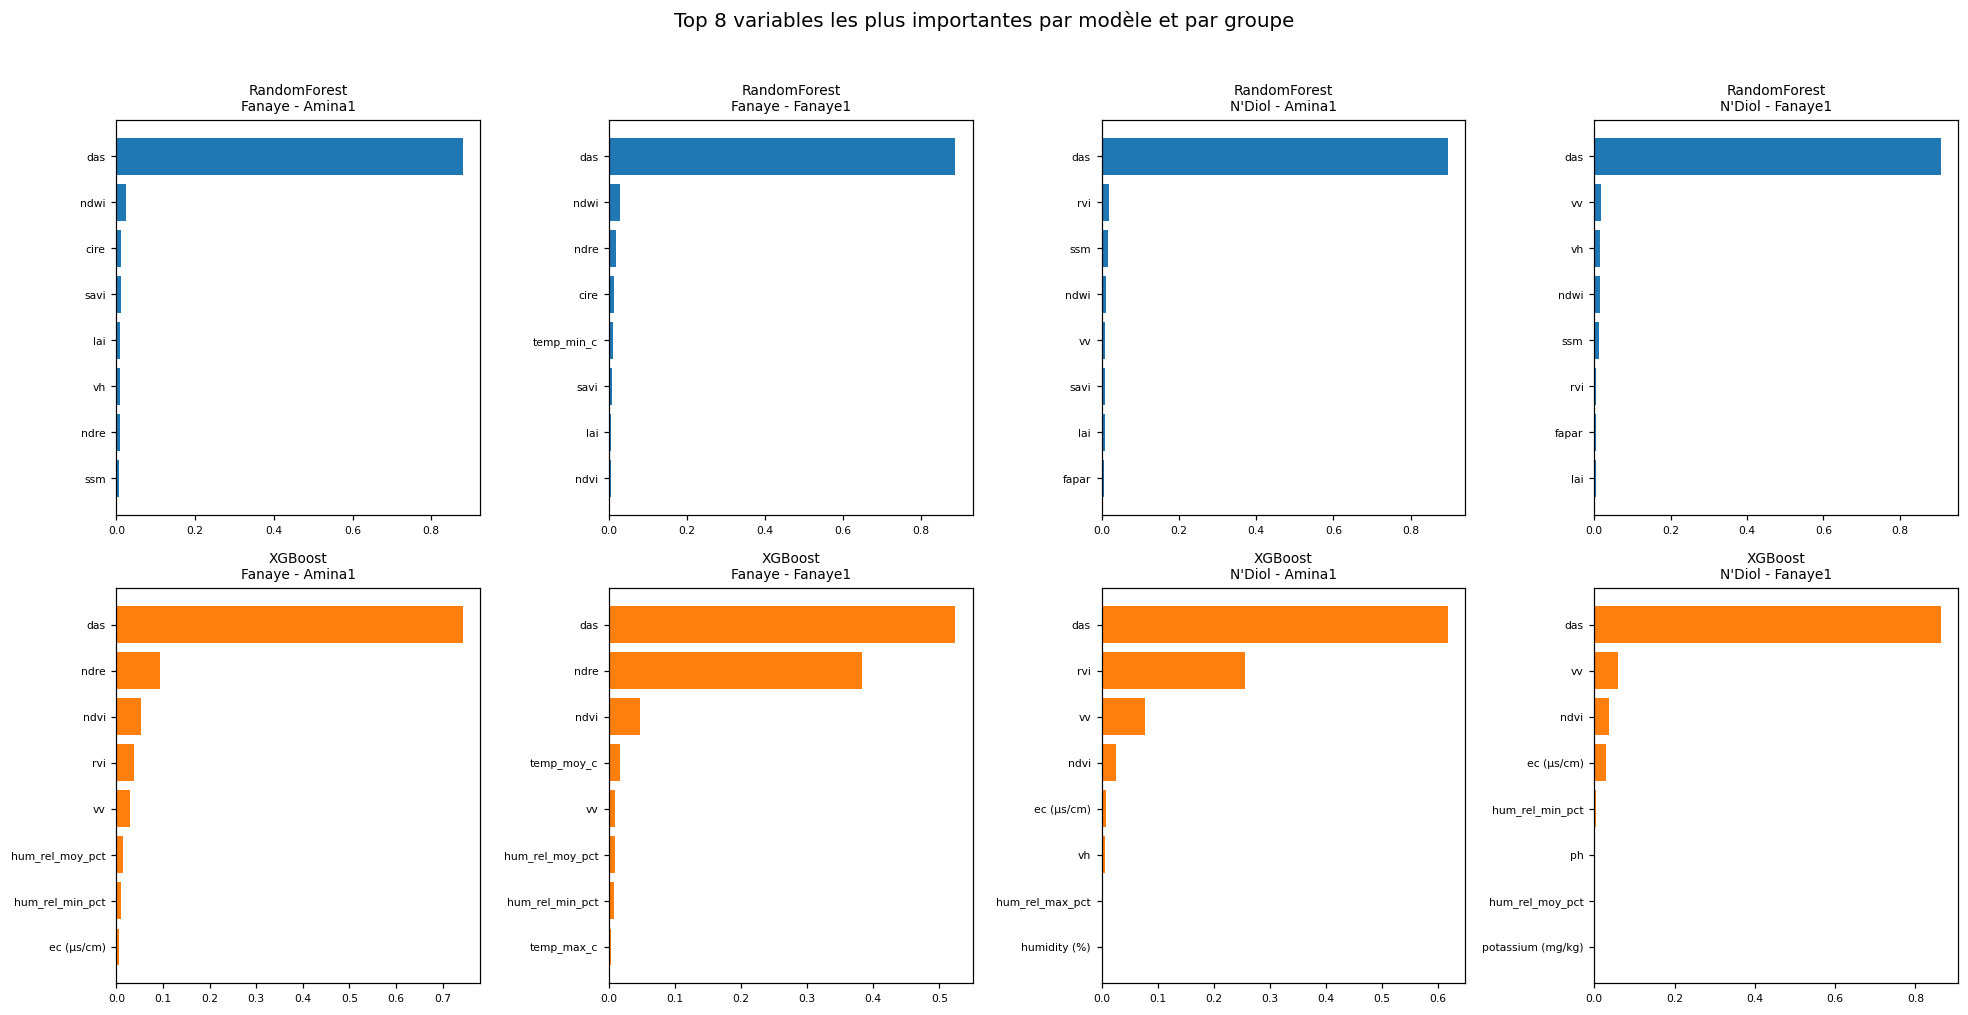

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (group_name, site, variete) in enumerate(groups):
    for row, model_type in enumerate(['RandomForest', 'XGBoost']):
        ax = axes[row, col]
        imp_df = feature_importance_store[(model_type, group_name)].head(8).iloc[::-1]
        ax.barh(imp_df['Feature'], imp_df['Importance'], color=model_colors[model_type])
        ax.set_title(f"{model_type}\n{site} - {variete}", fontsize=9)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

plt.suptitle("Top 8 variables les plus importantes par modèle et par groupe", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Note d'interprétation :** la variable `das` (jours après début de suivi) domine généralement très largement l'importance — logique puisque c'est l'horloge phénologique elle-même, fortement corrélée à `biomasse_cum` par construction. Pour obtenir une lecture plus fine du rôle **propre** des variables agro-climatiques et satellitaires, on répète l'analyse en excluant `das` (section 3.2).

### 3.2 Importance des variables sans `das` — lecture agro-satellitaire pure

In [ ]:
cols_to_exclude_no_das = cols_to_exclude + ['das']

rf_models_no_das = {}
xgb_models_no_das = {}
feature_importance_no_das = {}

for group_name, site, variete in groups:
    for model_type, store in [('RandomForest', rf_models_no_das), ('XGBoost', xgb_models_no_das)]:
        model, result, importances, preds_df, split_data = train_tree_model(
            df, site, variete, model_type, cols_to_exclude_no_das
        )
        store[group_name] = (model, split_data)
        feature_importance_no_das[(model_type, group_name)] = importances
        print(f"[{model_type} sans das] {site} / {variete} -> R²={result['R²']:.4f}")


[RandomForest sans das] Fanaye / Amina1 -> R²=0.8607
[XGBoost sans das] Fanaye / Amina1 -> R²=0.8994
[RandomForest sans das] Fanaye / Fanaye1 -> R²=0.8469
[XGBoost sans das] Fanaye / Fanaye1 -> R²=0.8792
[RandomForest sans das] N'Diol / Amina1 -> R²=0.9739
[XGBoost sans das] N'Diol / Amina1 -> R²=0.9875
[RandomForest sans das] N'Diol / Fanaye1 -> R²=0.8768
[XGBoost sans das] N'Diol / Fanaye1 -> R²=0.8226


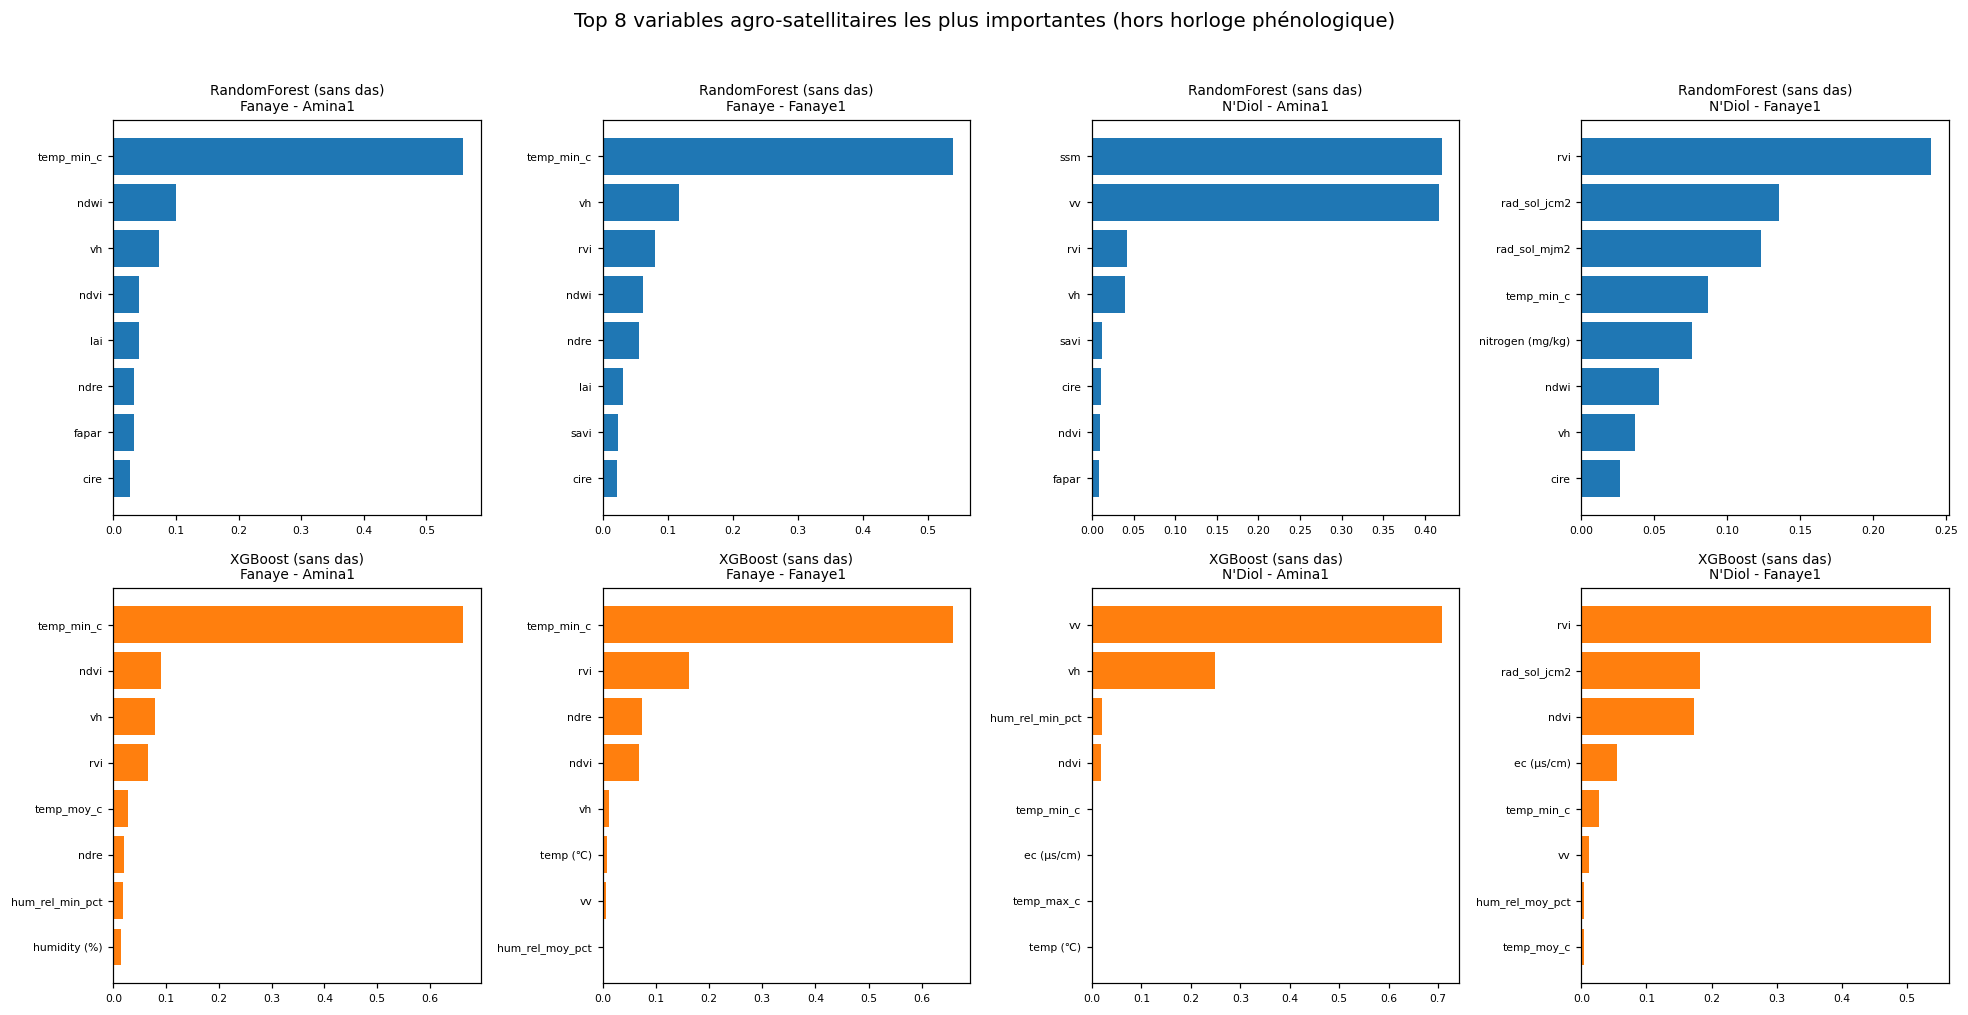

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (group_name, site, variete) in enumerate(groups):
    for row, model_type in enumerate(['RandomForest', 'XGBoost']):
        ax = axes[row, col]
        imp_df = feature_importance_no_das[(model_type, group_name)].head(8).iloc[::-1]
        ax.barh(imp_df['Feature'], imp_df['Importance'], color=model_colors[model_type])
        ax.set_title(f"{model_type} (sans das)\n{site} - {variete}", fontsize=9)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

plt.suptitle("Top 8 variables agro-satellitaires les plus importantes (hors horloge phénologique)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Analyse SHAP — XGBoost (sans `das`)

Les valeurs SHAP sont calculées sur les modèles XGBoost **sans `das`**, afin de mettre en évidence la contribution réelle des variables in-situ et satellitaires, indépendamment de l'effet temporel trivial. `shap.TreeExplainer` est l'explainer recommandé et exact pour les modèles à base d'arbres (RF, XGBoost).

In [ ]:
shap_values_store = {}
shap_data_store = {}

for group_name, site, variete in groups:
    model, (X_train, X_test, y_train, y_test) = xgb_models_no_das[group_name]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_values_store[group_name] = shap_values
    shap_data_store[group_name] = X_test
    print(f"SHAP calculé pour {site} / {variete} — {X_test.shape[0]} observations de test, {X_test.shape[1]} variables.")


SHAP calculé pour Fanaye / Amina1 — 16 observations de test, 28 variables.
SHAP calculé pour Fanaye / Fanaye1 — 16 observations de test, 28 variables.
SHAP calculé pour N'Diol / Amina1 — 18 observations de test, 28 variables.
SHAP calculé pour N'Diol / Fanaye1 — 18 observations de test, 28 variables.


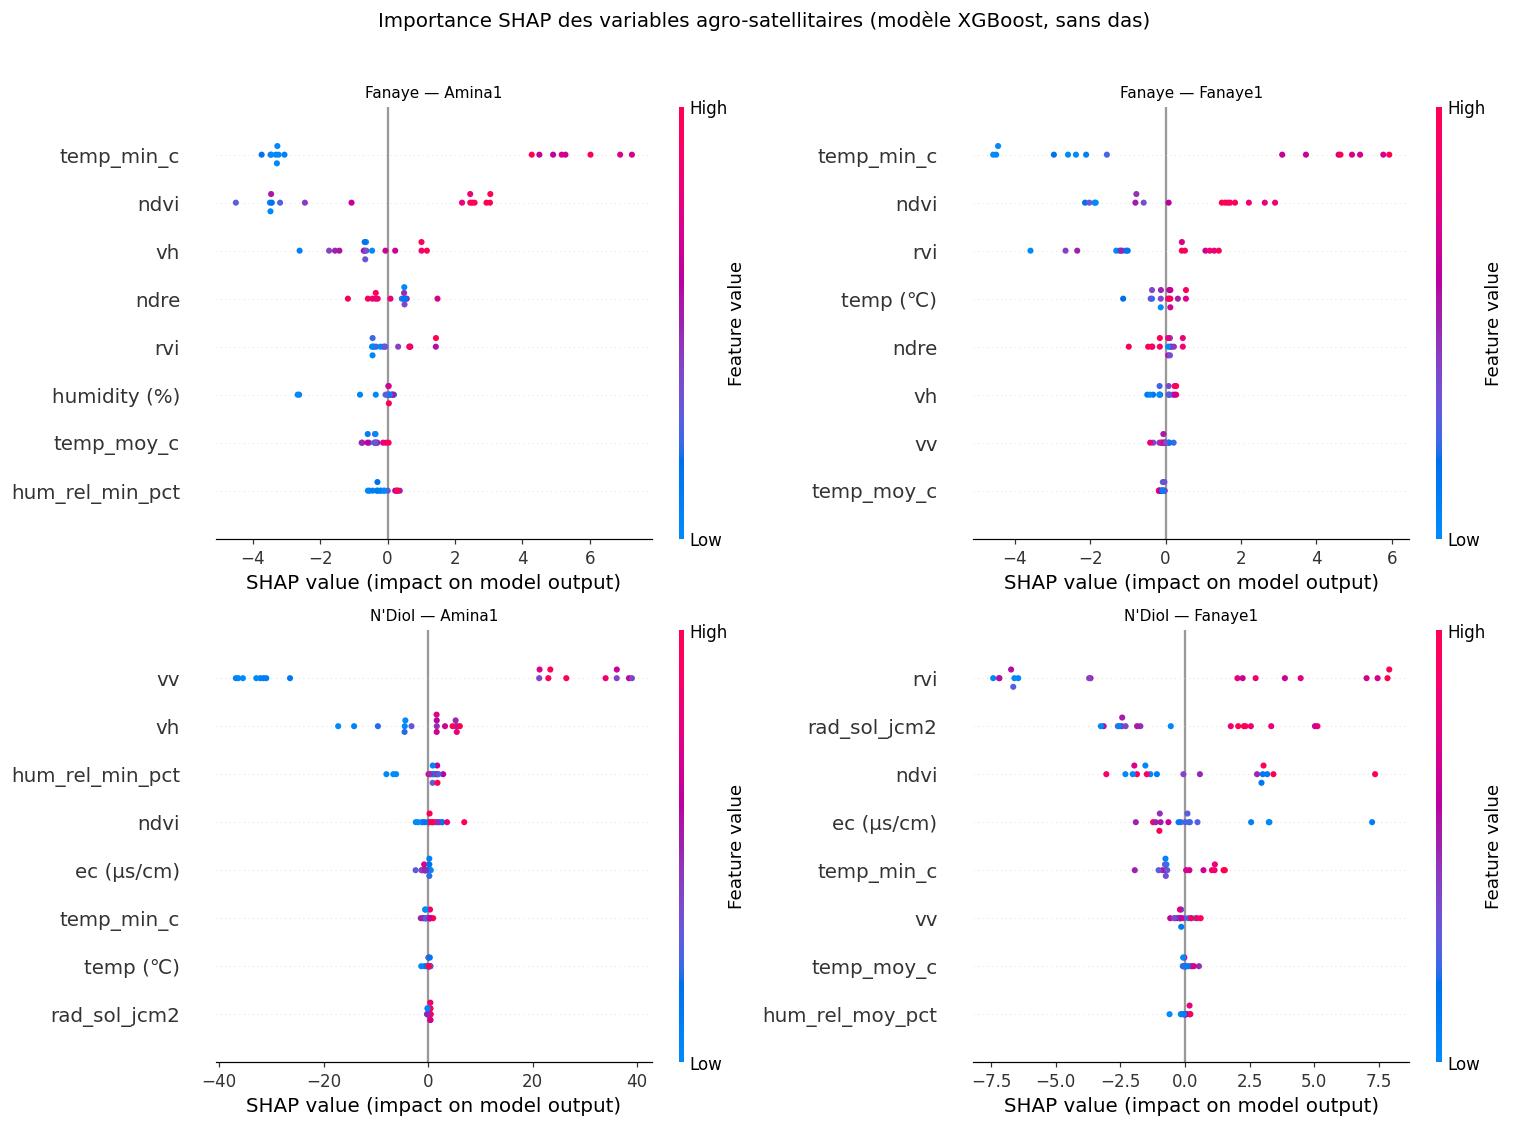

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    plt.sca(ax)
    shap.summary_plot(shap_values_store[group_name], shap_data_store[group_name],
                       show=False, plot_size=None, max_display=8)
    ax.set_title(f"{site} — {variete}", fontsize=10)

plt.suptitle("Importance SHAP des variables agro-satellitaires (modèle XGBoost, sans das)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Lecture du graphique SHAP (`summary_plot`) :** chaque point représente une observation de test. La position horizontale indique l'impact (positif ou négatif) de la variable sur la prédiction de biomasse pour cette observation ; la couleur indique le niveau de la variable (rouge = valeur élevée, bleu = valeur faible). Cela permet, par exemple, de vérifier si un NDVI élevé est associé à une contribution positive sur la biomasse prédite (cohérence agronomique attendue), ou si l'humidité du sol (`ssm`) joue un rôle différent selon le site (Fanaye vs N'Diol), ce qui éclairerait un effet pédoclimatique local.

### 3.4 Comparaison inter-sites et inter-variétés de l'importance SHAP moyenne

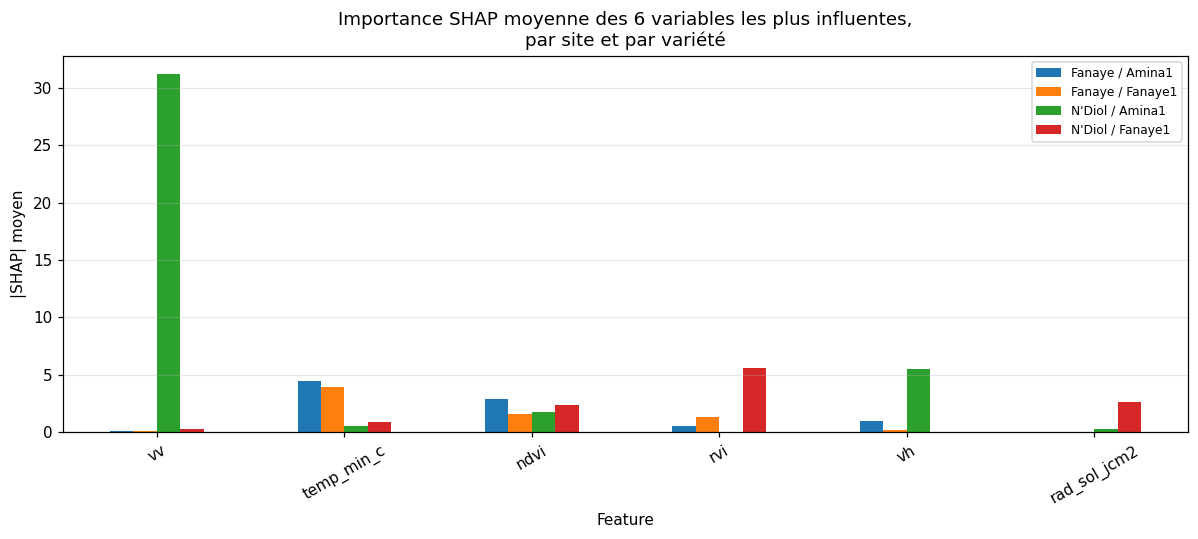

Groupe,Fanaye / Amina1,Fanaye / Fanaye1,N'Diol / Amina1,N'Diol / Fanaye1
Feature,,,,
vv,0.1276,0.1167,31.226601,0.2773
temp_min_c,4.4468,3.9359,0.546500,0.9068
ndvi,2.8944,1.6354,1.763100,2.3912
rvi,0.5108,1.3619,0.011100,5.6212
vh,0.9552,0.2159,5.539200,0.0685
rad_sol_jcm2,0.0616,0.0247,0.251600,2.6309


In [ ]:
mean_abs_shap = []
for group_name, site, variete in groups:
    sv = shap_values_store[group_name]
    Xte = shap_data_store[group_name]
    mean_abs = np.abs(sv).mean(axis=0)
    for feat, val in zip(Xte.columns, mean_abs):
        mean_abs_shap.append({'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
                               'Feature': feat, 'SHAP_moyen_abs': val})

shap_summary_df = pd.DataFrame(mean_abs_shap)

# Top 6 variables les plus influentes en moyenne sur l'ensemble des groupes
top_features = (shap_summary_df.groupby('Feature')['SHAP_moyen_abs'].mean()
                 .sort_values(ascending=False).head(6).index.tolist())

pivot_shap = shap_summary_df[shap_summary_df['Feature'].isin(top_features)].pivot(
    index='Feature', columns='Groupe', values='SHAP_moyen_abs'
).loc[top_features]

pivot_shap.plot(kind='bar', figsize=(11, 5))
plt.title("Importance SHAP moyenne des 6 variables les plus influentes,\npar site et par variété")
plt.ylabel("|SHAP| moyen")
plt.xticks(rotation=30)
plt.legend(title=None, fontsize=8)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

display(pivot_shap.round(4))


**Interprétation multicritère attendue :** si l'ordre ou l'amplitude des variables les plus influentes diffère entre Fanaye et N'Diol (ou entre Amina1 et Fanaye1), cela indique que **les déterminants de la croissance de la biomasse ne sont pas universels** mais dépendent du contexte pédoclimatique (site) et du patrimoine génétique (variété) — un résultat clé pour la discussion du mémoire, à mettre en regard des connaissances agronomiques disponibles sur ces variétés et sites (texture du sol, salinité, gestion de l'irrigation, etc.).

---
## Partie 4 — Synthèse comparative et export des résultats

### 4.1 Tableau de synthèse final (tous modèles, tous groupes)

In [ ]:
final_summary = results_df_sorted.copy()
final_summary['R²'] = final_summary['R²'].round(4)
final_summary['RMSE'] = final_summary['RMSE'].round(4)
final_summary['MAE'] = final_summary['MAE'].round(4)
display(final_summary)

print("\n=== Meilleur modèle par groupe (basé sur le RMSE le plus faible) ===")
best_per_group = final_summary.loc[final_summary.groupby('Groupe')['RMSE'].idxmin()]
display(best_per_group[['Groupe', 'Modèle', 'R²', 'RMSE', 'MAE']])


,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,RMSE,MAE
0,LSTM,Fanaye / Amina1,Fanaye,Amina1,79,64,15,0.9872,0.9177,0.7452
1,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.9992,0.2255,0.1659
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.9978,0.3845,0.2833
3,LSTM,Fanaye / Fanaye1,Fanaye,Fanaye1,79,64,15,0.9977,0.2889,0.2154
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.9993,0.1641,0.1211
5,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.9968,0.3413,0.2548
6,LSTM,N'Diol / Amina1,N'Diol,Amina1,85,68,17,0.9933,2.9432,2.5373
7,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.9977,1.7288,1.0113
8,XGBoost,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.9958,2.3573,1.4882
9,LSTM,N'Diol / Fanaye1,N'Diol,Fanaye1,85,68,17,0.9940,0.9833,0.8209



=== Meilleur modèle par groupe (basé sur le RMSE le plus faible) ===


,Groupe,Modèle,R²,RMSE,MAE
1,Fanaye / Amina1,RandomForest,0.9992,0.2255,0.1659
4,Fanaye / Fanaye1,RandomForest,0.9993,0.1641,0.1211
7,N'Diol / Amina1,RandomForest,0.9977,1.7288,1.0113
10,N'Diol / Fanaye1,RandomForest,0.9992,0.3602,0.2580


In [ ]:
final_summary = results_df_sorted.copy()
final_summary['R²'] = final_summary['R²'].round(4)
# Check if 'R² Ajusté' column exists before trying to round it
if 'R² Ajusté' in final_summary.columns:
    final_summary['R² Ajusté'] = final_summary['R² Ajusté'].round(4)
final_summary['RMSE'] = final_summary['RMSE'].round(4)
final_summary['MAE'] = final_summary['MAE'].round(4)
display(final_summary)

print("\n=== Meilleur modèle par groupe (basé sur le RMSE le plus faible) ===")
best_per_group = final_summary.loc[final_summary.groupby('Groupe')['RMSE'].idxmin()]

# Dynamically select columns for display to avoid KeyError if 'R² Ajusté' is missing
cols_to_display = ['Groupe', 'Modèle', 'R²']
if 'R² Ajusté' in final_summary.columns:
    cols_to_display.append('R² Ajusté')
cols_to_display.extend(['RMSE', 'MAE'])
display(best_per_group[cols_to_display])

,Modèle,Groupe,Site,Variété,Observations,N_train,N_test,R²,R² Ajusté,RMSE,MAE
0,LSTM,Fanaye / Amina1,Fanaye,Amina1,79,64,15,0.9874,NaN,0.9109,0.6637
1,RandomForest,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.9992,NaN,0.2255,0.1659
2,XGBoost,Fanaye / Amina1,Fanaye,Amina1,84,68,16,0.9978,NaN,0.3845,0.2833
3,LSTM,Fanaye / Fanaye1,Fanaye,Fanaye1,79,64,15,0.9942,NaN,0.4596,0.3481
4,RandomForest,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.9993,NaN,0.1641,0.1211
5,XGBoost,Fanaye / Fanaye1,Fanaye,Fanaye1,84,68,16,0.9968,NaN,0.3413,0.2548
6,LSTM,N'Diol / Amina1,N'Diol,Amina1,85,68,17,0.9859,NaN,4.2803,3.4693
7,RandomForest,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.9977,NaN,1.7288,1.0113
8,XGBoost,N'Diol / Amina1,N'Diol,Amina1,90,72,18,0.9958,NaN,2.3573,1.4882
9,LSTM,N'Diol / Fanaye1,N'Diol,Fanaye1,85,68,17,0.9810,NaN,1.7455,1.3323



=== Meilleur modèle par groupe (basé sur le RMSE le plus faible) ===


,Groupe,Modèle,R²,R² Ajusté,RMSE,MAE
1,Fanaye / Amina1,RandomForest,0.9992,NaN,0.2255,0.1659
4,Fanaye / Fanaye1,RandomForest,0.9993,NaN,0.1641,0.1211
7,N'Diol / Amina1,RandomForest,0.9977,NaN,1.7288,1.0113
10,N'Diol / Fanaye1,RandomForest,0.9992,NaN,0.3602,0.2580


### 4.2 Export complet des résultats (Excel)

Toutes les métriques, importances de variables et résumés SHAP sont exportés dans un classeur Excel unique, prêt à être inséré dans le mémoire (tableaux, annexes).

In [ ]:
output_path = 'resultats_biomasse_ble_dur_complet.xlsx'

with pd.ExcelWriter(output_path) as writer:
    final_summary.to_excel(writer, sheet_name='Synthese_Metriques', index=False)
    best_per_group.to_excel(writer, sheet_name='Meilleur_Modele_par_Groupe', index=False)

    for (model_type, group_name), imp_df in feature_importance_store.items():
        sheet_name = f"{model_type}_{group_name}_avecdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    for (model_type, group_name), imp_df in feature_importance_no_das.items():
        sheet_name = f"{model_type}_{group_name}_sansdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    shap_summary_df.to_excel(writer, sheet_name='SHAP_resume_par_groupe', index=False)
    pivot_shap.to_excel(writer, sheet_name='SHAP_top_variables')

print(f"Tous les résultats ont été exportés dans : {output_path}")


In [ ]:
output_path = 'resultats_biomasse_ble_dur_complet.xlsx'

with pd.ExcelWriter(output_path) as writer:
    final_summary.to_excel(writer, sheet_name='Synthese_Metriques', index=False)
    best_per_group.to_excel(writer, sheet_name='Meilleur_Modele_par_Groupe', index=False)

    for (model_type, group_name), imp_df in feature_importance_store.items():
        sheet_name = f"{model_type}_{group_name}_avecdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    for (model_type, group_name), imp_df in feature_importance_no_das.items():
        sheet_name = f"{model_type}_{group_name}_sansdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    shap_summary_df.to_excel(writer, sheet_name='SHAP_resume_par_groupe', index=False)
    pivot_shap.to_excel(writer, sheet_name='SHAP_top_variables')

print(f"Tous les résultats ont été exportés dans : {output_path}")

Tous les résultats ont été exportés dans : resultats_biomasse_ble_dur_complet.xlsx


In [ ]:
# Téléchargement automatique sur Google Colab (sans effet en local)
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print(f"Fichier disponible localement : {output_path}")


---
## Conclusion générale

Ce notebook a permis de :

1. **Corriger une erreur méthodologique critique** du notebook original : le split aléatoire train/test provoquait une fuite d'information temporelle, surestimant artificiellement la performance (R² ≈ 0.94–0.99 trompeur). Une stratégie de validation temporelle systématique, honnête et représentative du cas d'usage réel, a été mise en place et appliquée de façon identique à tous les modèles.

2. **Comparer trois familles de modèles d'IA** (Random Forest, XGBoost, LSTM) pour l'estimation de la biomasse aérienne cumulée, sur les 4 combinaisons Site (Fanaye, N'Diol) × Variété (Amina1, Fanaye1), avec des métriques strictement comparables (R², RMSE, MAE).

3. **Expliquer la dynamique de croissance** au-delà de la simple horloge phénologique (`das`), en isolant la contribution propre des variables in-situ (température, humidité, nutriments du sol) et satellitaires (indices optiques et radar), via la feature importance native et les valeurs SHAP — révélant des différences de déterminants entre sites et variétés, à discuter à la lumière des connaissances agronomiques du terrain.

**Pistes d'approfondissement possibles pour le mémoire :**
- Tester d'autres longueurs de fenêtre temporelle pour le LSTM (`WINDOW`) et comparer leur effet sur la performance.
- Élargir l'analyse SHAP aux interactions entre variables (`shap.dependence_plot`).
- Si davantage de campagnes/années sont disponibles à l'avenir, entraîner un modèle global multi-sites/multi-variétés (avec site et variété encodés en variables catégorielles) pour évaluer la capacité de généralisation inter-site, actuellement non testable avec un seul cycle de données par groupe.